Image successfully loaded! Shape dimensions: (300, 300)


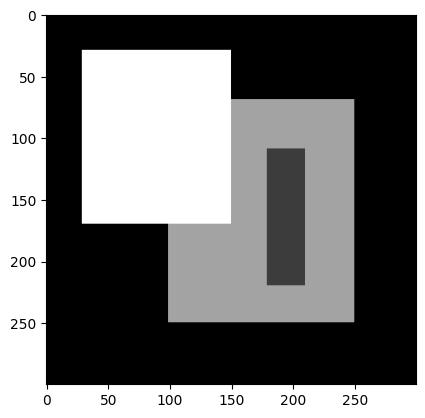

In [7]:
import cv2
import matplotlib.pyplot as plt 
import numpy as np 

im = cv2.imread('week06_data/TestIm1.png', cv2.IMREAD_GRAYSCALE).astype(float) / 255.0

plt.imshow(im, cmap='gray')
print(f"Image successfully loaded! Shape dimensions: {im.shape}")

Total crisp corners located in TestIm1: 8


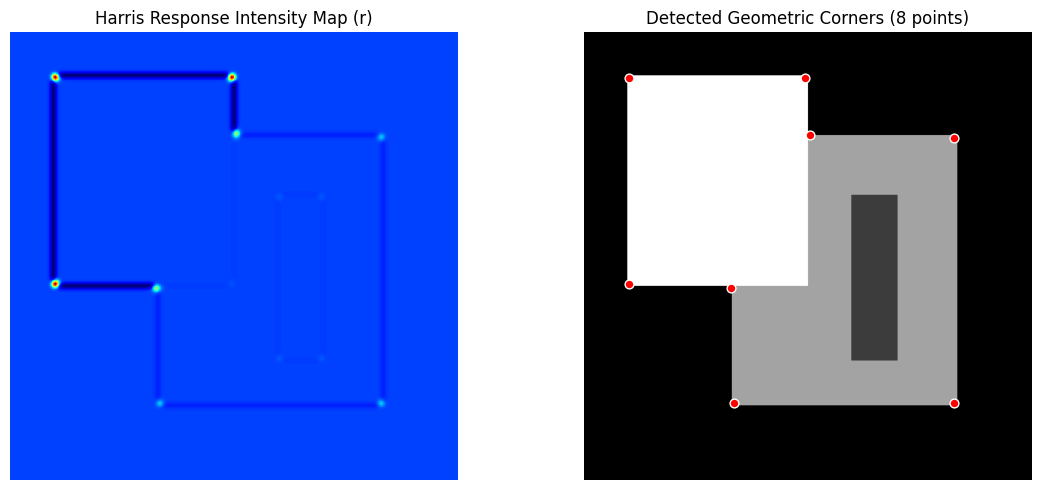

In [8]:
import cv2
import numpy as np
import scipy.ndimage as ndimage
import matplotlib.pyplot as plt

# ==============================================================================
# 1. THE HARRIS CORNER DETECTOR FUNCTION FROM SCRATCH
# ==============================================================================

def harris(im, sigma, epsilon, k=0.06, threshold_ratio=0.1):
    """
    Harris Corner Detector from scratch.
    
    Parameters:
    ---------
    im : numpy.ndarray
        Input grayscale image (2D float array normalized between 0.0 and 1.0).
    sigma : float
        Standard deviation for the initial Gaussian derivative filters.
    epsilon : float
        Standard deviation for the second Gaussian smoothing window.
    k : float
        Harris detector empirical sensitivity constant (typically 0.04 - 0.06).
    threshold_ratio : float
        Proportion of the maximum response value used as a lower-bound threshold.
        
    Returns:
    -------
    c : list of tuples
        List of detected corner coordinates [(x1, y1), (x2, y2), ...]
    r : numpy.ndarray
        The full 2D raw corner response map.
    """
    # Step 1: Compute Image Gradients using Gaussian derivatives
    # ndimage.gaussian_filter handles smoothing and derivation in a single fast command
    Ix = ndimage.gaussian_filter(im, sigma=sigma, order=[1, 0])
    Iy = ndimage.gaussian_filter(im, sigma=sigma, order=[0, 1])
    
    # Step 2: Compute Structure Tensor parts
    Ix2 = Ix ** 2
    Iy2 = Iy ** 2
    Ixy = Ix * Iy
    
    # Smooth the square components using a Gaussian window with scale 'epsilon'
    Cxx = ndimage.gaussian_filter(Ix2, sigma=epsilon)
    Cyy = ndimage.gaussian_filter(Iy2, sigma=epsilon)
    Cxy = ndimage.gaussian_filter(Ixy, sigma=epsilon)
    
    # Step 3: Compute the Corner Response map 'r'
    det_M = (Cxx * Cyy) - (Cxy ** 2)
    trace_M = Cxx + Cyy
    r = det_M - k * (trace_M ** 2)
    
    # Step 4: Non-Maximum Suppression (NMS)
    # Define a minimum threshold baseline to discard flat areas and edges
    threshold = threshold_ratio * r.max()
    
    # Find local 3x3 pixel max peaks using a maximum filter
    local_maxima = (r == ndimage.maximum_filter(r, size=(3, 3)))
    
    # Isolate corners where it's a local peak AND above our target response threshold
    corner_mask = local_maxima & (r > threshold)
    
    # Convert mask indices to list coordinates (y, x) -> (x, y) for standard plotting
    y_indices, x_indices = np.where(corner_mask)
    c = list(zip(x_indices, y_indices))
    
    return c, r

# ==============================================================================
# 2. APPLICATION ON SYNTHETIC TEST FRAME (TestIm1.png)
# ==============================================================================

# Load image cleanly as a single-channel grayscale float array
img_path = 'week06_data/TestIm1.png'
im1 = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

if im1 is None:
    raise FileNotFoundError(f"Could not load '{img_path}'. Ensure the path 'week06_data/' is right next to this notebook file.")

im1 = im1.astype(float) / 255.0

# Execute your Harris engine with initial baseline tuning variables
# (Small sigma/epsilon values keep the bounds crisp on sharp synthetic shapes)
corners, response_map = harris(im1, sigma=1.0, epsilon=2.0, k=0.05, threshold_ratio=0.1)

print(f"Total crisp corners located in TestIm1: {len(corners)}")

# Plotting the Verification Windows
fig, (ax_resp, ax_corners) = plt.subplots(1, 2, figsize=(12, 5))

# Plot response map intensities
ax_resp.imshow(response_map, cmap='jet')
ax_resp.set_title("Harris Response Intensity Map (r)")
ax_resp.axis('off')

# Plot image with corner markers dropped on top
ax_corners.imshow(im1, cmap='gray')
if len(corners) > 0:
    cx, cy = zip(*corners)
    ax_corners.scatter(cx, cy, color='red', marker='o', s=40, edgecolors='white', label='Corners')
ax_corners.set_title(f"Detected Geometric Corners ({len(corners)} points)")
ax_corners.axis('off')

plt.tight_layout()
plt.show()

Total crisp corners located in TestIm2: 14


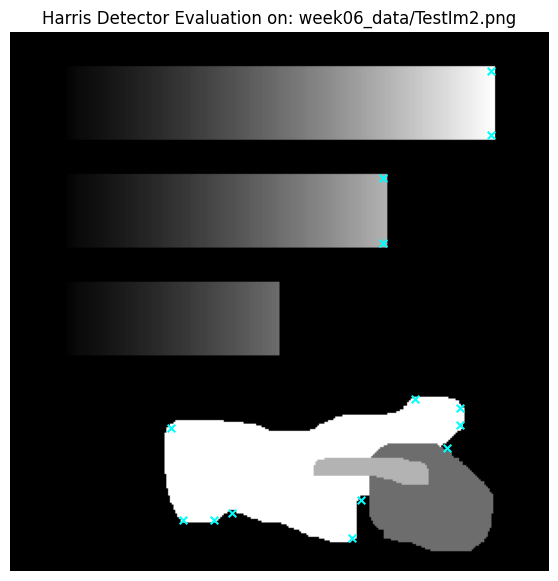

In [11]:
# Try loading a natural real-world dataset image
im2_path = 'week06_data/TestIm2.png'  # or any other image in your folder
im2_raw = cv2.imread(im2_path, cv2.IMREAD_GRAYSCALE)

if im2_raw is not None:
    im2 = im2_raw.astype(float) / 255.0
    
    # Real-world images have high-frequency pixel noise! 
    # Increasing sigma slightly (e.g., 2.0) smooths out sensor noise so it doesn't trick the detector
    corners_real, _ = harris(im2, sigma=2.0, epsilon=3.0, k=0.05, threshold_ratio=0.05)
    
    print(f"Total crisp corners located in TestIm2: {len(corners_real)}")

    plt.figure(figsize=(7, 7))
    plt.imshow(im2, cmap='gray')
    if len(corners_real) > 0:
        cx_r, cy_r = zip(*corners_real)
        plt.scatter(cx_r, cy_r, color='cyan', marker='x', s=30)
    plt.title(f"Harris Detector Evaluation on: {im2_path}")
    plt.axis('off')
    plt.show()

# 6.1

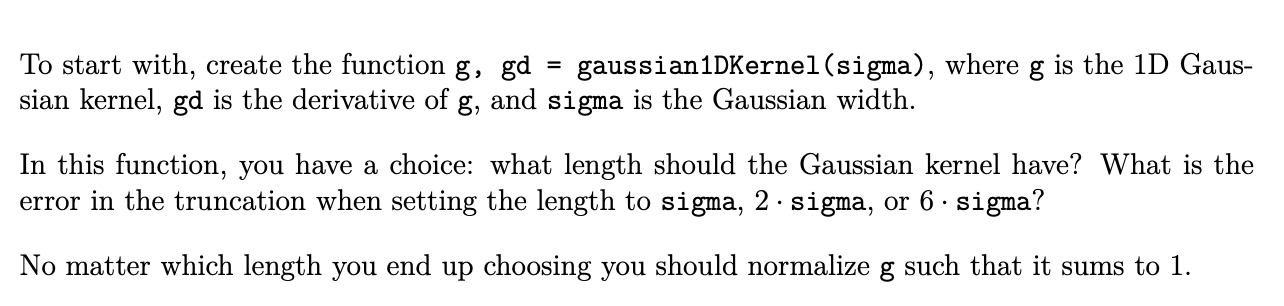

=================== EXERCISE 6.1 RESULTS ===================
For sigma = 2.0, a 3*sigma radius creates a kernel of length: 13
Verification Check -> Sum of smoothing kernel g: 1.00


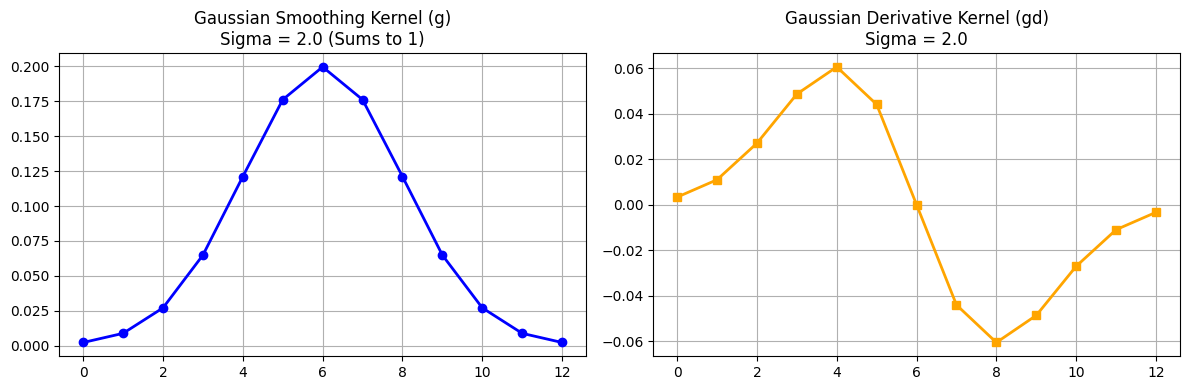

In [12]:
import numpy as np
import matplotlib.pyplot as plt

def gaussian1DKernel(sigma):
    """
    Creates a 1D Gaussian kernel and its analytical derivative.
    
    Parameters:
    ---------
    sigma : float
        The standard deviation (width) of the Gaussian distribution.
        
    Returns:
    -------
    g : numpy.ndarray
        The normalized 1D Gaussian smoothing kernel (sums to 1).
    gd : numpy.ndarray
        The 1D Gaussian derivative kernel.
    """
    # 1. Define the radius boundary out to 3 * sigma to achieve a 0.27% truncation error limit
    radius = int(np.ceil(3 * sigma))
    
    # 2. Generate symmetrical discrete integer coordinates centered at 0
    # e.g., if radius is 3, x becomes [-3, -2, -1,  0,  1,  2,  3]
    x = np.arange(-radius, radius + 1, dtype=float)
    
    # 3. Compute the unnormalized Gaussian values
    # Note: We can drop the 1/sqrt(2*pi)*sigma coefficient because we normalize explicitly at the end!
    g_unnormalized = np.exp(- (x ** 2) / (2 * (sigma ** 2)))
    
    # Normalize g so that the sum of all elements equals exactly 1.0
    g = g_unnormalized / np.sum(g_unnormalized)
    
    # 4. Compute the analytical derivative kernel gd
    # Derivative formula: gd(x) = -x / (sigma^2) * g(x)
    gd = -x / (sigma ** 2) * g
    
    return g, gd

# --- Test and Visualize Your Kernel response for sigma = 2.0 ---
sigma_test = 2.0
g, gd = gaussian1DKernel(sigma_test)

print("=================== EXERCISE 6.1 RESULTS ===================")
print(f"For sigma = {sigma_test}, a 3*sigma radius creates a kernel of length: {len(g)}")
print(f"Verification Check -> Sum of smoothing kernel g: {np.sum(g):.2f}")

# Plotting the shapes to verify analytical symmetry
fig, (ax_g, ax_gd) = plt.subplots(1, 2, figsize=(12, 4))

ax_g.plot(g, marker='o', color='blue', linewidth=2)
ax_g.set_title(f"Gaussian Smoothing Kernel (g)\nSigma = {sigma_test} (Sums to 1)")
ax_g.grid(True)

ax_gd.plot(gd, marker='s', color='orange', linewidth=2)
ax_gd.set_title(f"Gaussian Derivative Kernel (gd)\nSigma = {sigma_test}")
ax_gd.grid(True)

plt.tight_layout()
plt.show()

# 6.2

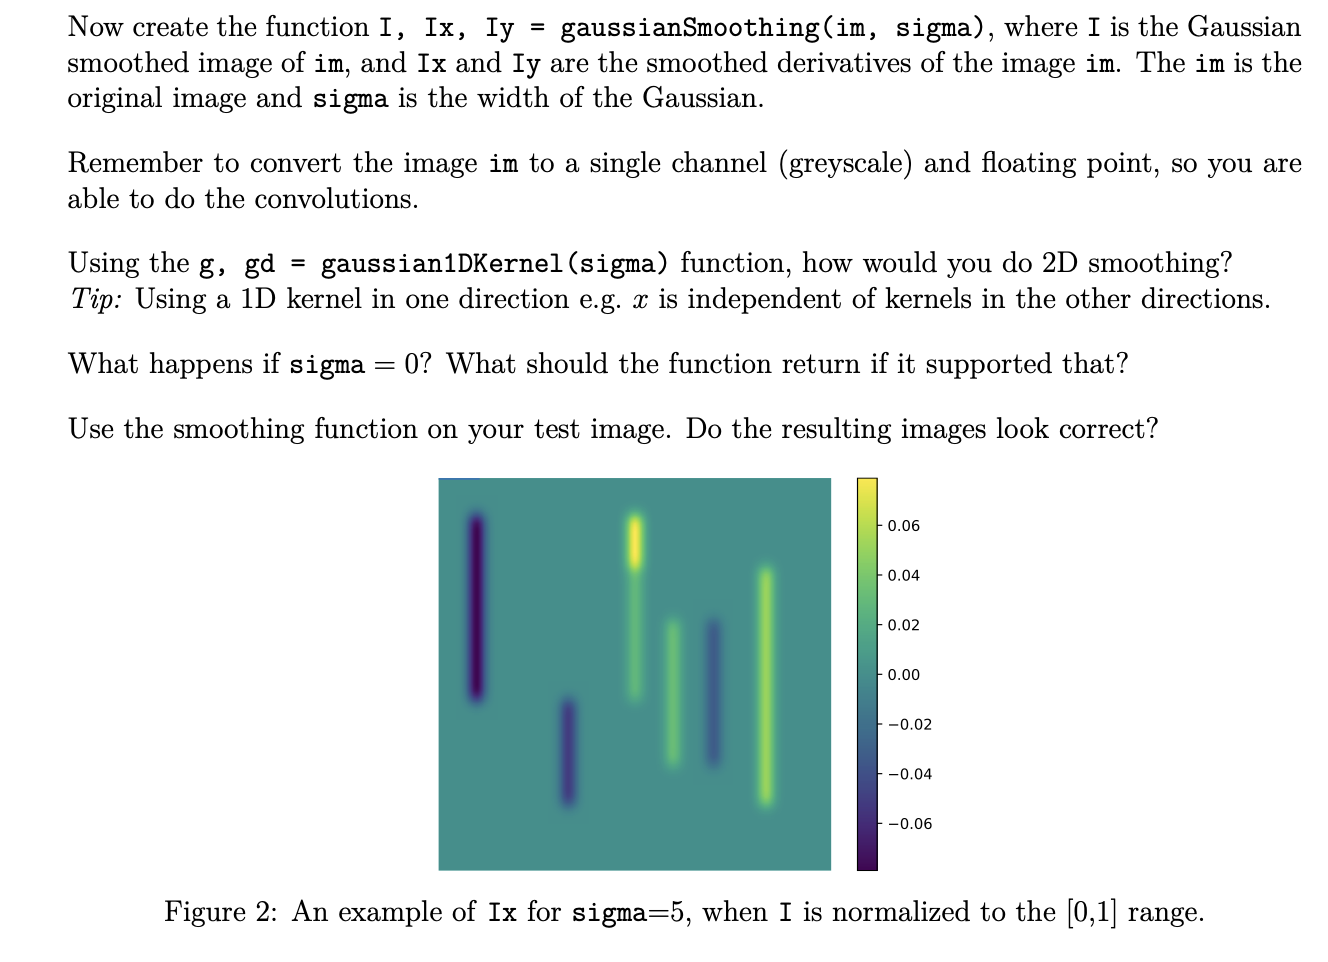

In [13]:
import numpy as np
import cv2
import scipy.ndimage as ndimage
import matplotlib.pyplot as plt

# --- 1. Pull in your 1D Kernel Builder from Exercise 6.1 ---
def gaussian1DKernel(sigma):
    radius = int(np.ceil(3 * sigma))
    x = np.arange(-radius, radius + 1, dtype=float)
    g_unnormalized = np.exp(- (x ** 2) / (2 * (sigma ** 2)))
    g = g_unnormalized / np.sum(g_unnormalized)
    gd = -x / (sigma ** 2) * g
    return g, gd

# --- 2. Implement the 2D Separable Smoothing Function ---
def gaussianSmoothing(im, sigma):
    """
    Smoothes an image and computes its spatial derivatives using 1D separable filters.
    
    Parameters:
    ---------
    im : numpy.ndarray
        Input single-channel grayscale image (float type).
    sigma : float
        Standard deviation for the Gaussian filter.
    """
    # Handle the boundary edge case where sigma is zero
    if sigma == 0:
        # No smoothing is applied
        I = im.copy()
        # Fall back to standard discrete central differences
        Ix = ndimage.convolve1d(im, np.array([-0.5, 0, 0.5]), axis=1)
        Iy = ndimage.convolve1d(im, np.array([-0.5, 0, 0.5]), axis=0)
        return I, Ix, Iy
        
    # Generate our analytical 1D baseline tracking arrays
    g, gd = gaussian1DKernel(sigma)
    
    # Pass A: Compute fully smoothed image I
    # Convolve along rows (axis=1) then columns (axis=0)
    I_row = ndimage.convolve1d(im, g, axis=1)
    I = ndimage.convolve1d(I_row, g, axis=0)
    
    # Pass B: Compute horizontal spatial gradient Ix
    # Apply derivative along rows (axis=1), then smooth along columns (axis=0)
    Ix_row = ndimage.convolve1d(im, gd, axis=1)
    Ix = ndimage.convolve1d(Ix_row, g, axis=0)
    
    # Pass C: Compute vertical spatial gradient Iy
    # Smooth along rows (axis=1), then apply derivative along columns (axis=0)
    Iy_row = ndimage.convolve1d(im, g, axis=1)
    Iy = ndimage.convolve1d(Iy_row, gd, axis=0)
    
    return I, Ix, Iy

=================== EXERCISE 6.2 EVALUATION ===================
Smoothed Intensity Bounds -> Min: -0.0790, Max: 0.0790


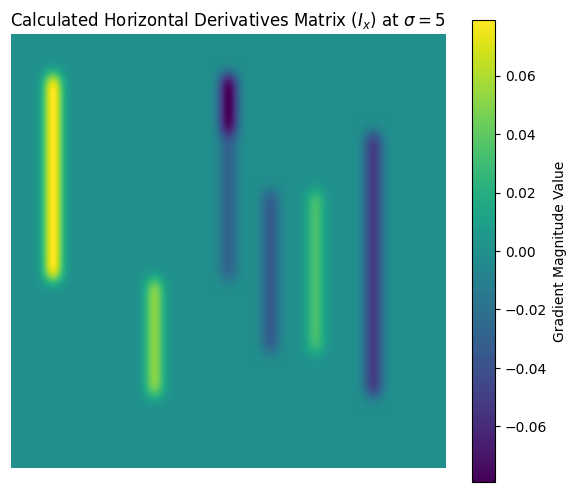

In [14]:
# Load the test frame as a floating-point grayscale image array
im_test = cv2.imread('week06_data/TestIm1.png', cv2.IMREAD_GRAYSCALE).astype(float) / 255.0

# Execute your separable smoothing engine
I_smooth, Ix, Iy = gaussianSmoothing(im_test, sigma=5.0)

print("=================== EXERCISE 6.2 EVALUATION ===================")
print(f"Smoothed Intensity Bounds -> Min: {Ix.min():.4f}, Max: {Ix.max():.4f}")

# Plot your horizontal gradient to match the assignment figure
plt.figure(figsize=(7, 6))
plt.imshow(Ix, cmap='viridis')  # 'viridis' maps beautifully to the slide colorbar profile
plt.colorbar(label='Gradient Magnitude Value')
plt.title("Calculated Horizontal Derivatives Matrix ($I_x$) at $\sigma = 5$")
plt.axis('off')
plt.show()

# 6.3

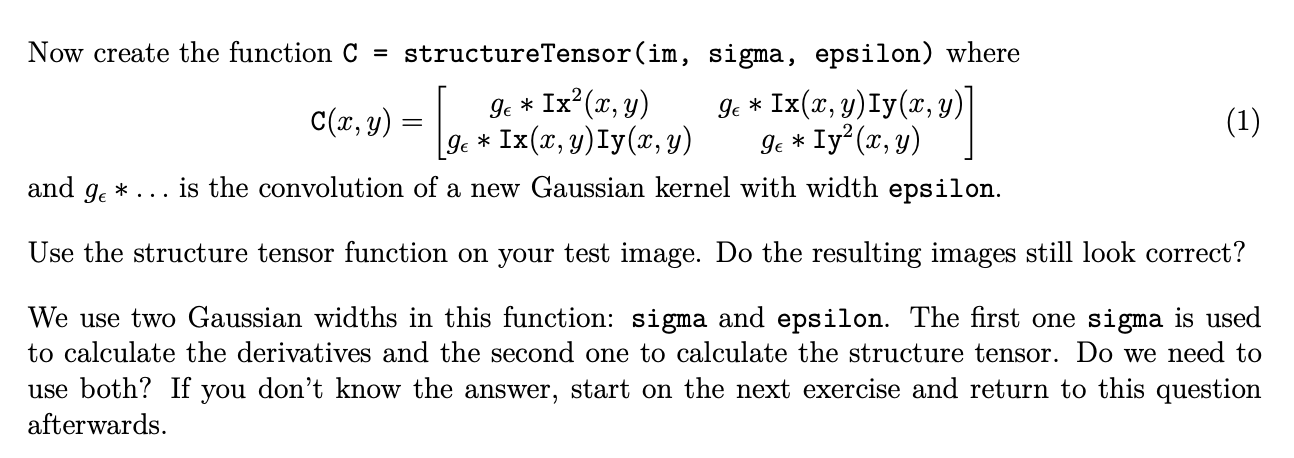

In [15]:
import numpy as np
import scipy.ndimage as ndimage

# --- Helper 1D Kernel Generator from Ex 6.1 ---
def gaussian1DKernel(sigma):
    radius = int(np.ceil(3 * sigma))
    x = np.arange(-radius, radius + 1, dtype=float)
    g = np.exp(- (x ** 2) / (2 * (sigma ** 2)))
    return g / np.sum(g), -x / (sigma ** 2) * (g / np.sum(g))

# --- Helper 2D Smoothing Tool from Ex 6.2 ---
def gaussianSmoothing(im, sigma):
    g, gd = gaussian1DKernel(sigma)
    I = ndimage.convolve1d(ndimage.convolve1d(im, g, axis=1), g, axis=0)
    Ix = ndimage.convolve1d(ndimage.convolve1d(im, gd, axis=1), g, axis=0)
    Iy = ndimage.convolve1d(ndimage.convolve1d(im, g, axis=1), gd, axis=0)
    return I, Ix, Iy

# --- 2D Structure Tensor Generator ---
def structureTensor(im, sigma, epsilon):
    """
    Computes the 2D spatial structure tensor components for an image array.
    
    Returns:
    -------
    Cxx, Cyy, Cxy : numpy.ndarrays
        The three unique smoothed matrix components of the structure tensor.
    """
    # 1. Step A: Compute the smoothed spatial derivatives using scale 'sigma'
    _, Ix, Iy = gaussianSmoothing(im, sigma)
    
    # 2. Step B: Calculate raw pixel-wise squares and product matrices
    Ix2 = Ix ** 2
    Iy2 = Iy ** 2
    Ixy = Ix * Iy
    
    # 3. Step C: Smooth the raw product maps using a Gaussian window with scale 'epsilon'
    # Generate the separate neighborhood kernel filter array
    g_eps, _ = gaussian1DKernel(epsilon)
    
    # Apply separable 1D row/column convolutions across all three matrix channels
    Cxx = ndimage.convolve1d(ndimage.convolve1d(Ix2, g_eps, axis=1), g_eps, axis=0)
    Cyy = ndimage.convolve1d(ndimage.convolve1d(Iy2, g_eps, axis=1), g_eps, axis=0)
    Cxy = ndimage.convolve1d(ndimage.convolve1d(Ixy, g_eps, axis=1), g_eps, axis=0)
    
    return Cxx, Cyy, Cxy

In [16]:
import cv2

# Load and scale the synthetic shape frame
im_cube = cv2.imread('week06_data/TestIm1.png', cv2.IMREAD_GRAYSCALE).astype(float) / 255.0

# Run your structure tensor compiler
Cxx, Cyy, Cxy = structureTensor(im_cube, sigma=1.0, epsilon=2.0)

print("=================== STRUCTURE TENSOR DIAGNOSTICS ===================")
print(f"Cxx (Horizontal Energy) Range -> Min: {Cxx.min():.4f}, Max: {Cxx.max():.4f}")
print(f"Cyy (Vertical Energy) Range   -> Min: {Cyy.min():.4f}, Max: {Cyy.max():.4f}")

=================== STRUCTURE TENSOR DIAGNOSTICS ===================
Cxx (Horizontal Energy) Range -> Min: 0.0000, Max: 0.0540
Cyy (Vertical Energy) Range   -> Min: 0.0000, Max: 0.0540


# 6.4 

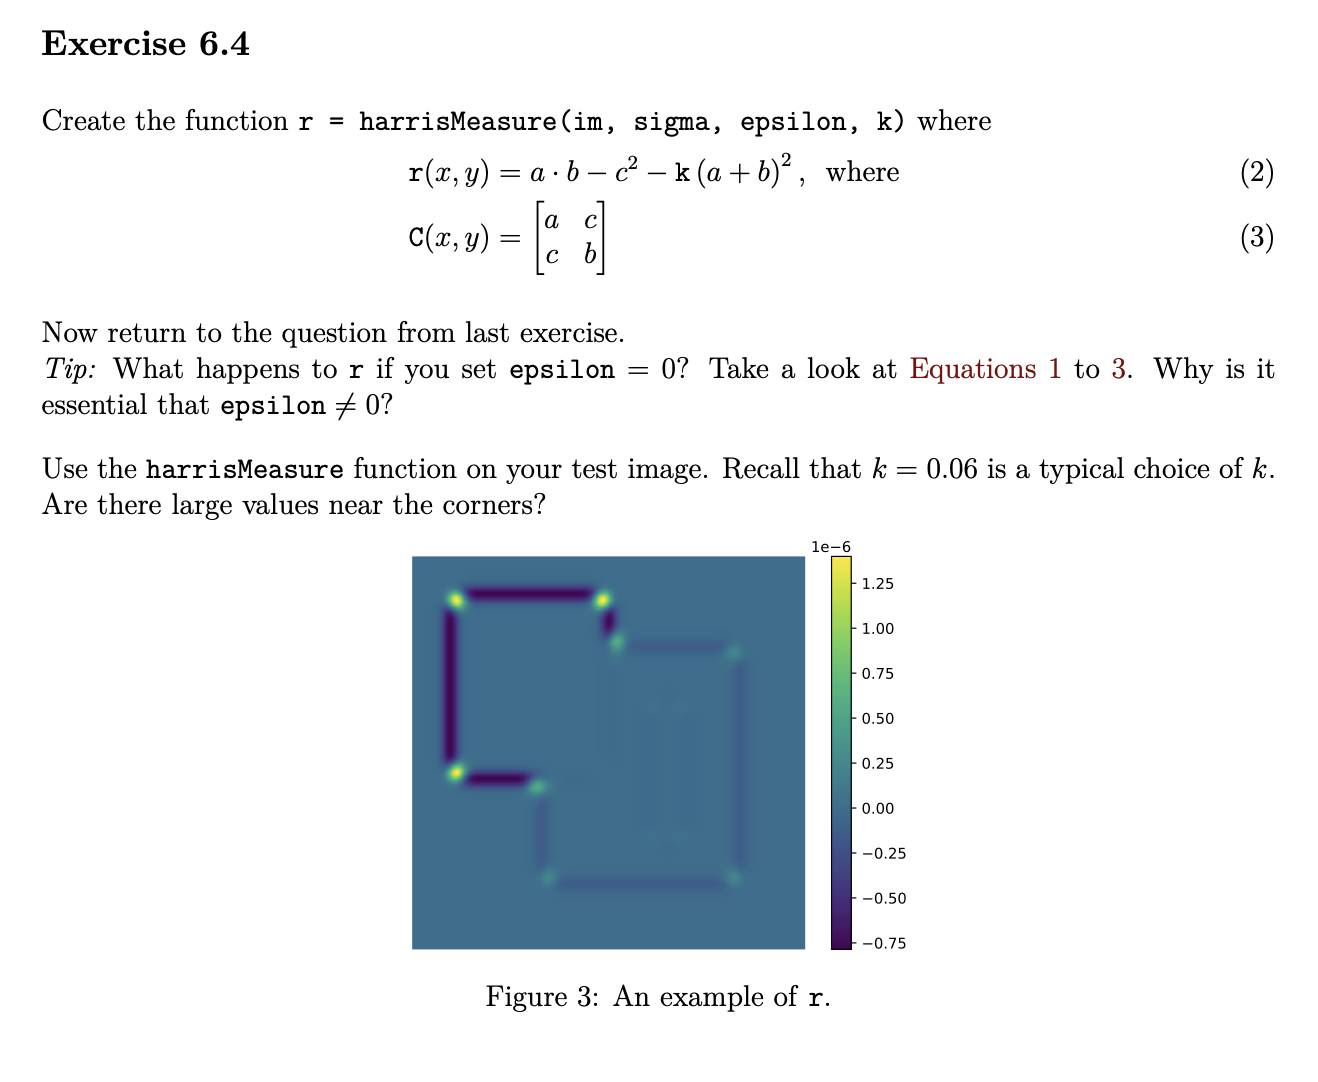

In [17]:
import numpy as np
import scipy.ndimage as ndimage

# --- Helper 1D Kernel Generator (Ex 6.1) ---
def gaussian1DKernel(sigma):
    radius = int(np.ceil(3 * sigma))
    x = np.arange(-radius, radius + 1, dtype=float)
    g = np.exp(- (x ** 2) / (2 * (sigma ** 2)))
    return g / np.sum(g), -x / (sigma ** 2) * (g / np.sum(g))

# --- Helper 2D Structure Tensor Compiler (Ex 6.2 & 6.3) ---
def structureTensor(im, sigma, epsilon):
    g_sig, gd_sig = gaussian1DKernel(sigma)
    g_eps, _ = gaussian1DKernel(epsilon)
    
    # Compute image gradients
    Ix = ndimage.convolve1d(ndimage.convolve1d(im, gd_sig, axis=1), g_sig, axis=0)
    Iy = ndimage.convolve1d(ndimage.convolve1d(im, g_sig, axis=1), gd_sig, axis=0)
    
    # Smooth products with integration scale epsilon
    a = ndimage.convolve1d(ndimage.convolve1d(Ix**2, g_eps, axis=1), g_eps, axis=0)
    b = ndimage.convolve1d(ndimage.convolve1d(Iy**2, g_eps, axis=1), g_eps, axis=0)
    c = ndimage.convolve1d(ndimage.convolve1d(Ix*Iy, g_eps, axis=1), g_eps, axis=0)
    
    return a, b, c

# --- Exercise 6.4: Harris Corner Measure Function ---
def harrisMeasure(im, sigma, epsilon, k=0.06):
    """
    Computes the raw Harris corner response map r.
    """
    # 1. Compile the integrated second-moment matrix components
    a, b, c = structureTensor(im, sigma, epsilon)
    
    # 2. Compute the response matrix using the determinant and trace shortcut
    # r = det(C) - k * trace(C)^2
    r = (a * b - c**2) - k * ((a + b) ** 2)
    
    return r

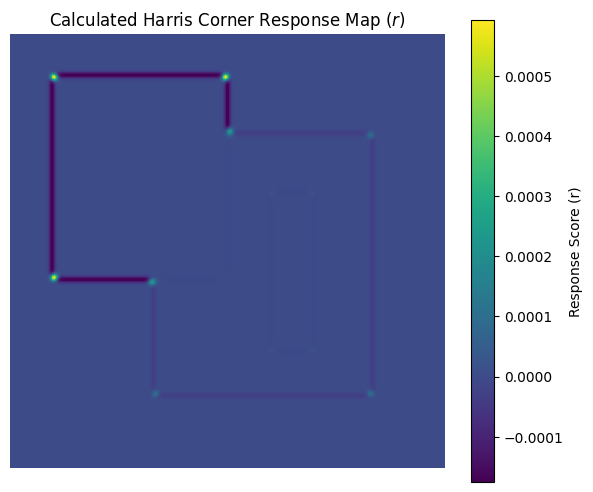

=================== DICTIONARY ANALYSIS ===================
Maximum positive score found: 5.9299e-04
Minimum negative score found: -1.7518e-04


In [18]:
import cv2
import matplotlib.pyplot as plt

# Load test image as grayscale float array
im_verify = cv2.imread('week06_data/TestIm1.png', cv2.IMREAD_GRAYSCALE).astype(float) / 255.0

# Generate Harris response map
r_map = harrisMeasure(im_verify, sigma=1.0, epsilon=2.0, k=0.06)

# Plot the intensity landscape
plt.figure(figsize=(7, 6))
plt.imshow(r_map, cmap='viridis')
plt.colorbar(label='Response Score (r)')
plt.title("Calculated Harris Corner Response Map ($r$)")
plt.axis('off')
plt.show()

# Quick Sanity Check: Are there large values near the corners?
print("=================== DICTIONARY ANALYSIS ===================")
print(f"Maximum positive score found: {r_map.max():.4e}")
print(f"Minimum negative score found: {r_map.min():.4e}")

# 6.5

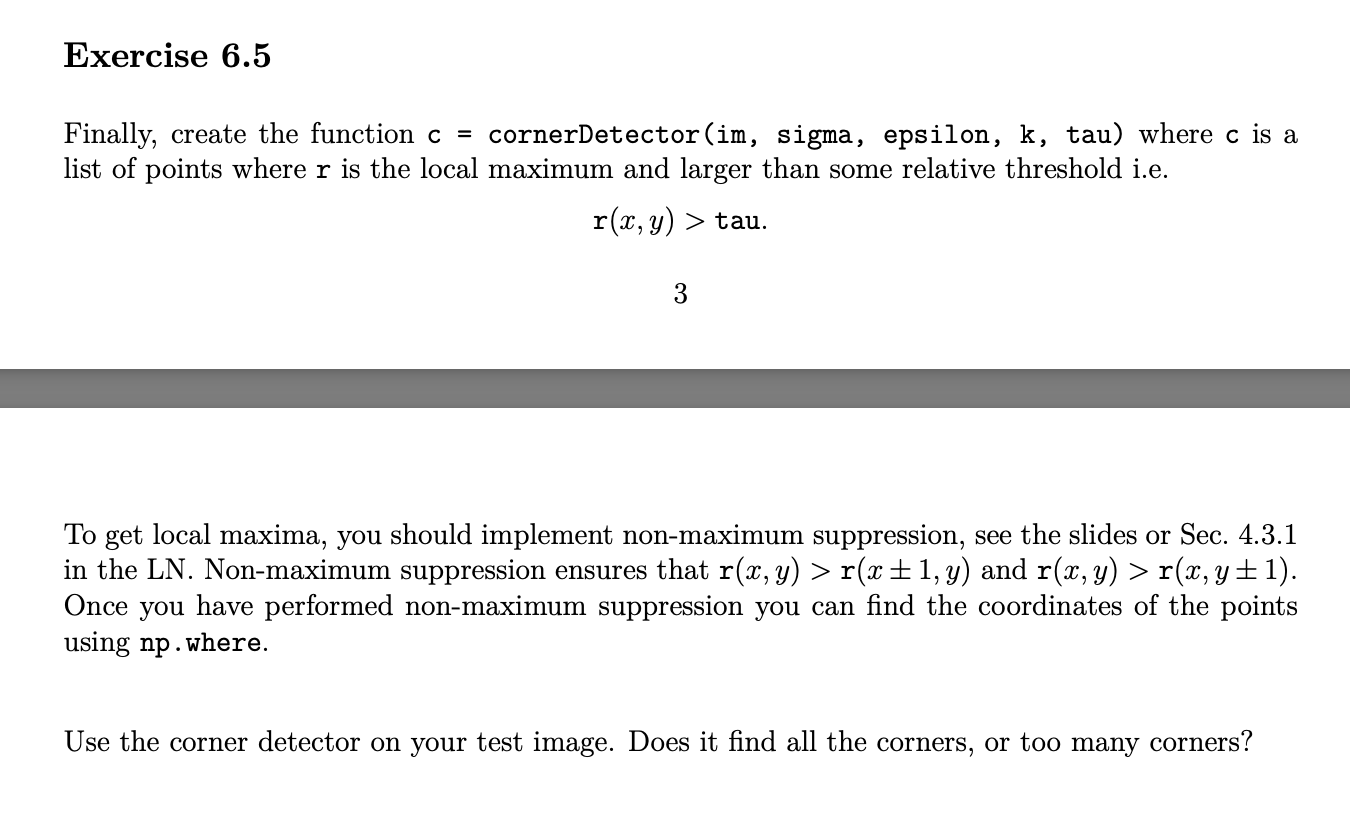

In [19]:
import numpy as np
import scipy.ndimage as ndimage
import cv2
import matplotlib.pyplot as plt

# --- 1. Combined Helper Matrix Builders from Exercises 6.1 - 6.4 ---
def gaussian1DKernel(sigma):
    radius = int(np.ceil(3 * sigma))
    x = np.arange(-radius, radius + 1, dtype=float)
    g = np.exp(- (x ** 2) / (2 * (sigma ** 2)))
    return g / np.sum(g), -x / (sigma ** 2) * (g / np.sum(g))

def harrisMeasure(im, sigma, epsilon, k=0.06):
    g_sig, gd_sig = gaussian1DKernel(sigma)
    g_eps, _ = gaussian1DKernel(epsilon)
    
    Ix = ndimage.convolve1d(ndimage.convolve1d(im, gd_sig, axis=1), g_sig, axis=0)
    Iy = ndimage.convolve1d(ndimage.convolve1d(im, g_sig, axis=1), gd_sig, axis=0)
    
    a = ndimage.convolve1d(ndimage.convolve1d(Ix**2, g_eps, axis=1), g_eps, axis=0)
    b = ndimage.convolve1d(ndimage.convolve1d(Iy**2, g_eps, axis=1), g_eps, axis=0)
    c = ndimage.convolve1d(ndimage.convolve1d(Ix*Iy, g_eps, axis=1), g_eps, axis=0)
    
    return (a * b - c**2) - k * ((a + b) ** 2)

# --- 2. Exercise 6.5: Final Corner Detector Function ---
def cornerDetector(im, sigma, epsilon, k, tau):
    """
    Finds sharp features using Harris responses and non-maximum suppression.
    
    Parameters:
    ---------
    im : numpy.ndarray
        Grayscale input image.
    tau : float
        Absolute threshold value for the corner response metric.
        
    Returns:
    -------
    c : numpy.ndarray
        An Nx2 array containing the detected corner coordinates [[x1, y1], [x2, y2], ...]
    """
    # Step A: Compute the raw continuous response map r
    r = harrisMeasure(im, sigma, epsilon, k)
    
    # Step B: Perform non-maximum suppression using a 3x3 pixel window
    # This checks if a pixel is strictly larger than or equal to its 8 neighbors
    local_maxima_mask = (r == ndimage.maximum_filter(r, size=(3, 3)))
    
    # Step C: Combine peak tracking mask with the absolute threshold criteria
    valid_corners_mask = local_maxima_mask & (r > tau)
    
    # Step D: Extract indices via np.where. 
    # Note: np.where returns (row, col) which maps to (y, x). We flip to get (x, y).
    y_indices, x_indices = np.where(valid_corners_mask)
    
    # Stack columns into an (N, 2) output matrix
    c = np.column_stack((x_indices, y_indices))
    
    return c

=================== CORNER DETECTOR EVALUATION ===================
Total isolated point coordinates discovered: 13


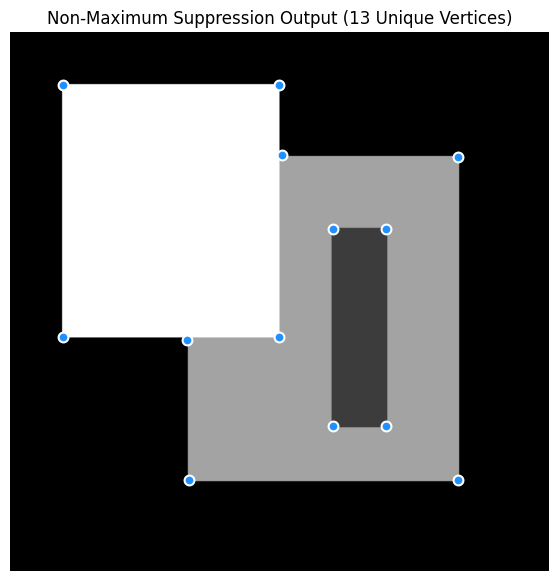

In [21]:
# Load image as grayscale float array
im_shapes = cv2.imread('week06_data/TestIm1.png', cv2.IMREAD_GRAYSCALE).astype(float) / 255.0

# REFERENCE TUNING: Setting a smaller absolute tau captures the lower-contrast inner rectangle!
sigma_val = 1.0
epsilon_val = 1.0
k_val = 0.06
tau_tuned = 1e-5  # A low absolute threshold allows subtler features to pass

detected_points = cornerDetector(im_shapes, sigma=sigma_val, epsilon=epsilon_val, k=k_val, tau=tau_tuned)

print("=================== CORNER DETECTOR EVALUATION ===================")
print(f"Total isolated point coordinates discovered: {len(detected_points)}")

# Render matching visualization layout
plt.figure(figsize=(7, 7))
plt.imshow(im_shapes, cmap='gray')
if len(detected_points) > 0:
    plt.scatter(detected_points[:, 0], detected_points[:, 1], color='dodgerblue', marker='o', s=50, edgecolors='white', linewidths=1.5)
plt.title(f"Non-Maximum Suppression Output ({len(detected_points)} Unique Vertices)")
plt.axis('off')
plt.show()

# 6.6

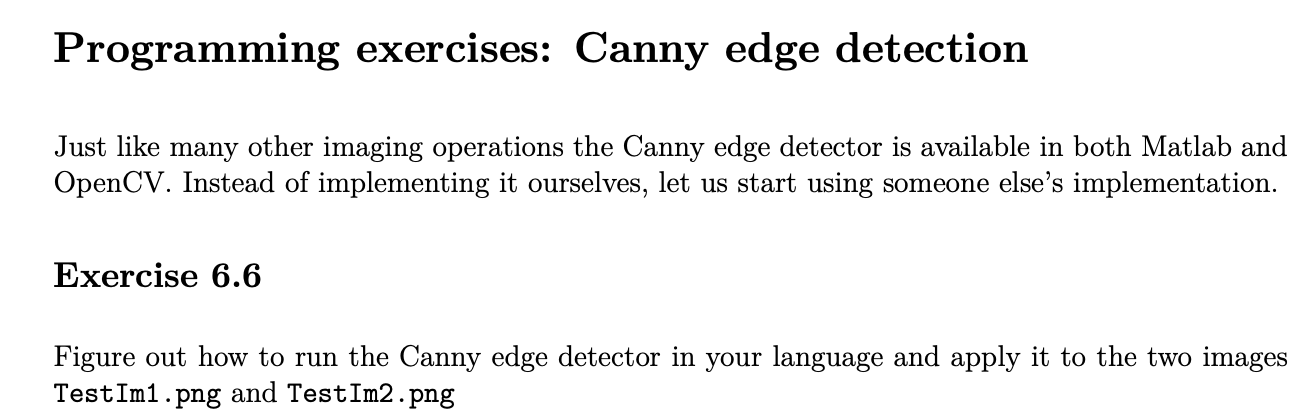

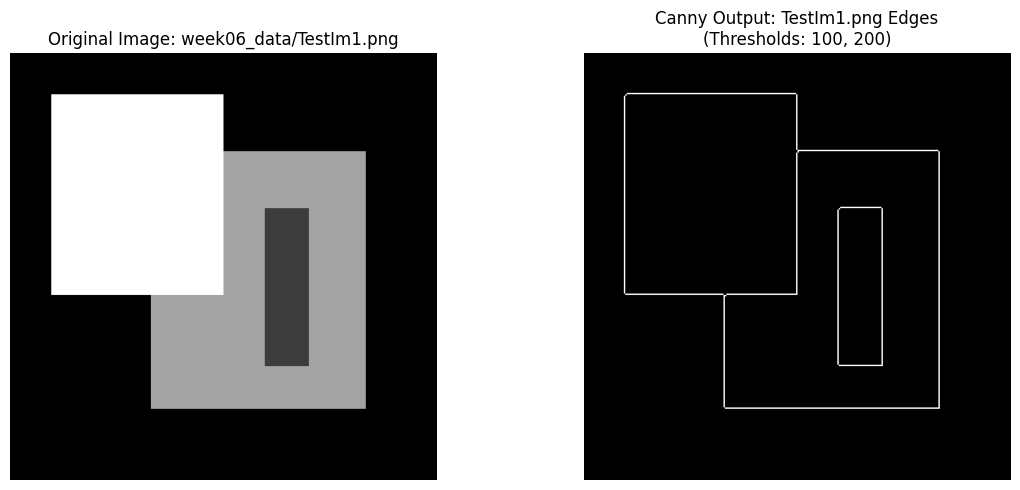

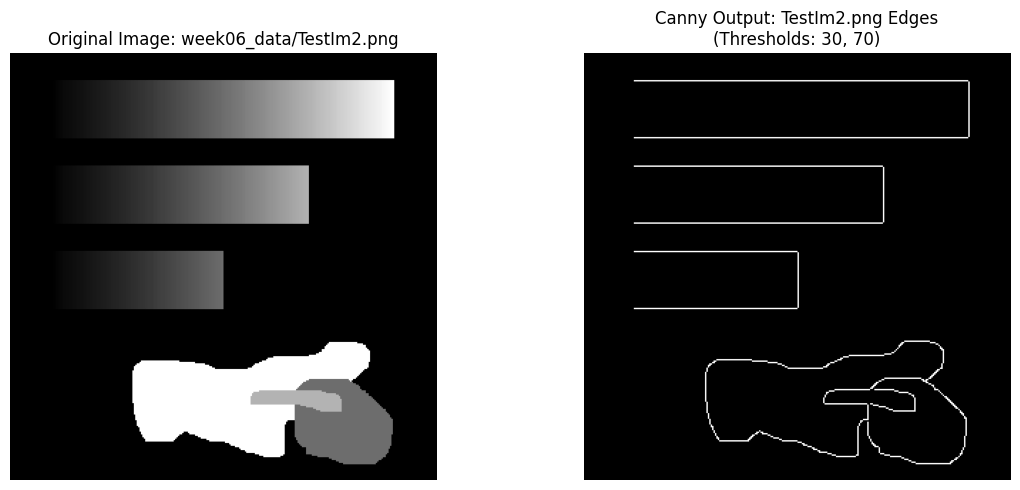

In [22]:
# cv2.Canny(im1, t1,t2)

import cv2
import numpy as np
import matplotlib.pyplot as plt

# ==============================================================================
# 1. DEFINE CANNY PROCESSING PIPELINE
# ==============================================================================

def run_canny_detector(image_path, t1, t2):
    """
    Loads an image in grayscale and applies OpenCV's Canny edge detector.
    """
    # Load raw file as single-channel grayscale
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        print(f"Warning: Could not load {image_path}. Please check your path.")
        return None
        
    # cv2.Canny internally handles Gaussian smoothing and hysteresis tracking
    edges = cv2.Canny(img, threshold1=t1, threshold2=t2)
    return img, edges

# ==============================================================================
# 2. RUN AND VISUALIZE EDGES ON TESTIM1 & TESTIM2
# ==============================================================================

# Define path locations matching your week6 project directory structure
im1_path = 'week06_data/TestIm1.png'
im2_path = 'week06_data/TestIm2.png'

# Tuning parameters:
# - TestIm1 has clean, perfect geometric contrast step-boundaries.
# - TestIm2 has soft, smooth gradient transitions, requiring lower thresholds.
data_runs = [
    {"path": im1_path, "t1": 100, "t2": 200, "title": "TestIm1.png Edges"},
    {"path": im2_path, "t1": 30,  "t2": 70,  "title": "TestIm2.png Edges"}
]

for run in data_runs:
    result = run_canny_detector(run["path"], run["t1"], run["t2"])
    if result is None:
        continue
        
    gray_img, edge_map = result
    
    # Plot input vs extracted binary edge mask side-by-side
    fig, (ax_orig, ax_edge) = plt.subplots(1, 2, figsize=(12, 5))
    
    ax_orig.imshow(gray_img, cmap='gray')
    ax_orig.set_title(f"Original Image: {run['path']}")
    ax_orig.axis('off')
    
    # Render edges as white strokes on a black canvas background
    ax_edge.imshow(edge_map, cmap='gray')
    ax_edge.set_title(f"Canny Output: {run['title']}\n(Thresholds: {run['t1']}, {run['t2']})")
    ax_edge.axis('off')
    
    plt.tight_layout()
    plt.show()

The final output of cv2.Canny() is a pure binary image mask (a 2D matrix consisting entirely of 0s and 255s)
* Every background pixel where no significant gradient structure was found is set to a pixel weight of 0 (rendered as solid black).
* Every single-pixel-wide line that survived both the directional peak-finder and the hysteresis gate is set to a weight of 255 (rendered as sharp white strokes).

# 6.7 

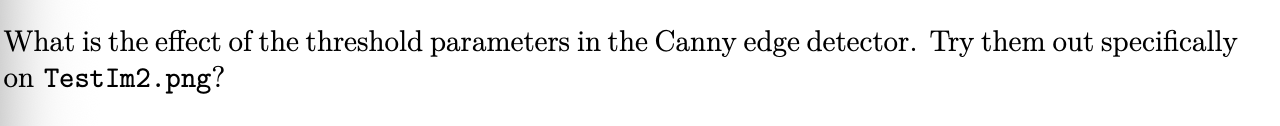

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, IntSlider

# --- 1. Load the Grayscale Image Target ---
image_path = 'week06_data/TestIm2.png'
img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

if img is None:
    print(f"Error: Could not locate data frame at {image_path}")
else:
    # --- 2. Define the Matplotlib Inline Rendering Target Function ---
    def update_canny(t1, t2):
        # Run Canny edge tracking pipeline
        edges = cv2.Canny(img, threshold1=t1, threshold2=t2)
        
        # Plot the outputs cleanly inline without spawning OS desktop windows
        plt.figure(figsize=(8, 6))
        plt.imshow(edges, cmap='gray')
        plt.title(f"Jupyter Inline Canny Edges (t1: {t1}, t2: {t2})")
        plt.axis('off')
        plt.show()

    # --- 3. Generate Native Notebook Slider Overlays ---
    interact(
        update_canny, 
        t1=IntSlider(min=0, max=255, step=1, value=30, description='Lower t1:'),
        t2=IntSlider(min=0, max=255, step=1, value=70, description='Upper t2:')
    )

interactive(children=(IntSlider(value=30, description='Lower t1:', max=255), IntSlider(value=70, description='…

* You should use Canny Edge Detection when your primary goal is to extract structural boundaries, silhouettes, outlines, or shape contours from an image.
* If your task relies on knowing where shapes begin and end (like finding the boundary lines of a road, tracking the profile of an object, or detecting coins), Canny is your go-to algorithm.

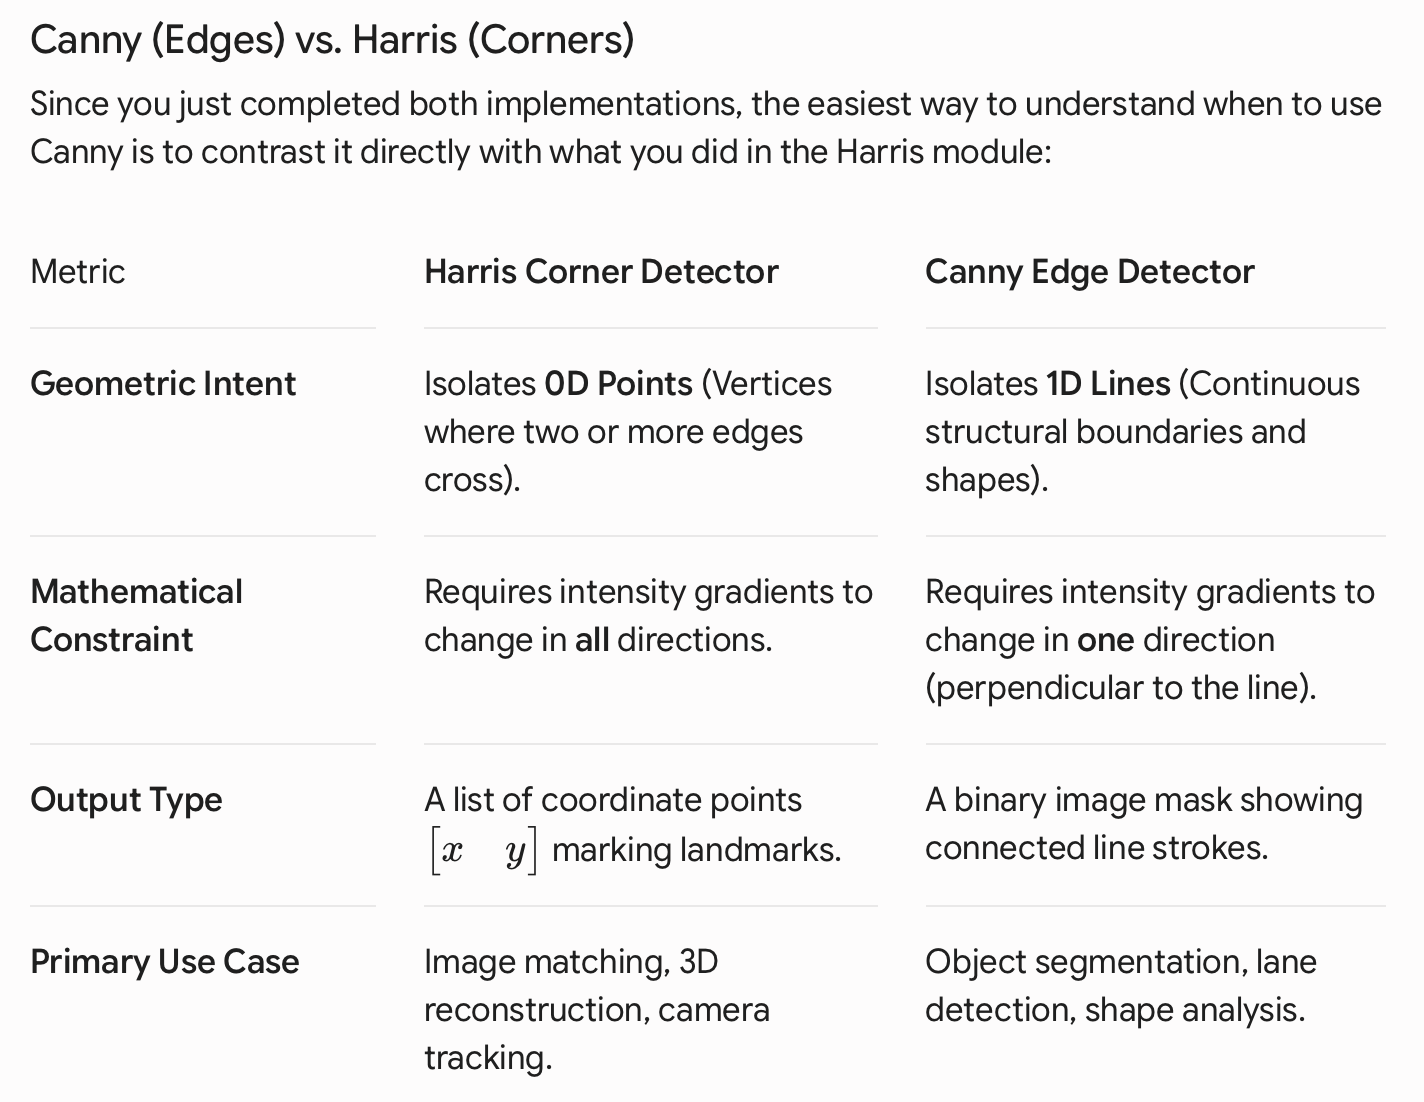

When to not use CANNY 

Canny is highly effective, but it will fail or degrade performance in these environments:
* High-Texture Regions: If you run Canny on a tree full of leaves, a patch of grass, or a gravel road, it will explode into a messy "hairball" of thousands of irrelevant tiny edge segments. Canny expects clear structural shapes, not dense textures.

* Feature Matching Across Views: If you need to match features between two different camera viewpoints to calculate depth (like your Week 5 triangulation exercise), lines are incredibly difficult to match uniquely because points can slide anywhere along the line (known as the aperture problem). For matching, you need distinct, localized anchor points—which is exactly when you swap Canny out for Harris Corners.